# 02 · Model experiments

How much do the features beyond Elo help, and what does XGBoost add? Everything here uses **only the
training and validation seasons (2019-20 to 2024-25)**. The 2025-26 test season is scored once, in
`python -m src.evaluate`, and is not used to make any choice in this notebook.

In [1]:
import sys
import warnings
sys.path.insert(0, "..")  # make the project's src/ package importable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", message="IProgress not found")  # harmless notice from shap's progress bar
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "figure.dpi": 110})
OUTCOME_COLORS = {"H": "#2a78d6", "D": "#a3a29c", "A": "#eb6834"}
from sklearn.metrics import log_loss
from src.features import ELO_FEATURES, FEATURES, FORM_FEATURES, OTHER_FEATURES, VENUE_FEATURES
from src.train import CV_SEASONS, SEED, TRAIN_SEASONS, VALID_SEASON, load_features, make_model, time_split, tune, XGB_GRID

features = load_features()
train, valid, _ = time_split(features)
played = pd.concat([train, valid])
print(f"Train {len(train)} matches, validation {len(valid)} matches")

Train 1900 matches, validation 380 matches


## Validation: train on 2019-20 to 2023-24, score on 2024-25
Saved by `python -m src.train`. The simple Elo-only logistic regression gives the best validation log loss.

In [2]:
pd.read_csv('../reports/validation_results.csv')

,model,log_loss,accuracy
0,Baseline,1.0799,0.4079
1,LogReg (Elo),0.9773,0.5447
2,LogReg (all),0.9842,0.5395
3,XGBoost,0.9898,0.5421


## Feature-group ablation (expanding-window CV)
Logistic regression (scaled, best C per feature set from the same grid as `src/train.py`) on growing feature sets, averaged over three folds (each fold season is predicted
by a model trained only on the seasons before it). If extra features carried new signal, the log loss would drop.

In [3]:
from src.train import LOGREG_GRID

def cv_logloss(columns, C):
    seasons = TRAIN_SEASONS + [VALID_SEASON]
    losses = []
    for fold in CV_SEASONS:
        past = played[played["Season"].isin(seasons[: seasons.index(fold)])]
        test = played[played["Season"] == fold]
        model = make_model("LogReg (all)", {"C": C}).fit(past[columns], past["target"].astype(int))
        losses.append(log_loss(test["target"], model.predict_proba(test[columns]), labels=[0, 1, 2]))
    return np.mean(losses)

groups = {
    "Elo difference only": ["elo_diff"],
    "All Elo columns": ELO_FEATURES,
    "Elo + last-5 form": ELO_FEATURES + FORM_FEATURES,
    "Elo + home/away form": ELO_FEATURES + VENUE_FEATURES,
    "All features": FEATURES,
}
rows = []
for name, cols in groups.items():
    scores = {C: cv_logloss(cols, C) for C in LOGREG_GRID["C"]}
    best_C = min(scores, key=scores.get)
    rows.append({"features": name, "n_features": len(cols), "best_C": best_C, "cv_log_loss": scores[best_C]})
pd.DataFrame(rows).round(4)

,features,n_features,best_C,cv_log_loss
0,Elo difference only,1,1.00,0.9647
1,All Elo columns,3,1.00,0.9639
2,Elo + last-5 form,15,0.01,0.9660
3,Elo + home/away form,11,0.03,0.9666
4,All features,27,0.01,0.9693


Adding form features makes the CV log loss slightly **worse** (0.9639 for the three Elo columns vs 0.9660-0.9693
with form added). Elo already summarises recent results, and last-5 averages mostly add noise. This is the main
reason the richer models do not beat the Elo-only model.

## XGBoost tuning
A small grid over depth, learning rate and number of trees, scored by the same expanding-window CV. The winner uses
**depth-1 trees** (stumps), and the top of the table is dominated by the most constrained settings (shallow trees,
slow learning). The differences are small, but the direction is clear: with roughly 2,000 training matches, the data
supports only simple, additive effects.

In [4]:
best, results = tune("XGBoost", XGB_GRID, features)
print("best:", best)
results.head(8).round(4)

best: {'max_depth': 1, 'learning_rate': 0.02, 'n_estimators': 400}


,max_depth,learning_rate,n_estimators,cv_log_loss
5,1,0.02,400,0.9723
7,1,0.05,200,0.9728
11,2,0.01,400,0.9731
15,2,0.05,100,0.9733
6,1,0.05,100,0.9737
13,2,0.02,200,0.9749
20,3,0.01,400,0.9757
4,1,0.02,200,0.9761


## Why no model predicts draws
The best validation model's draw probabilities, next to the bookmaker's. Neither ever makes a draw the single most
likely outcome, so draws (about a quarter of matches) are always "wrong" for accuracy, even when the probabilities
are well calibrated.

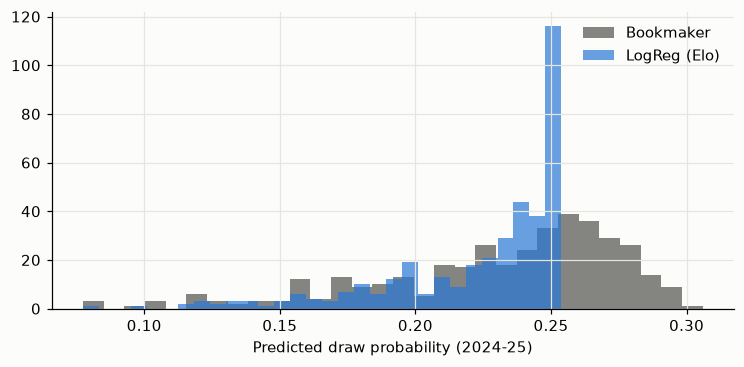

Actual draw rate: 24.5%; model draw prob range: 7.7%-25.4%


In [5]:
from src.evaluate import bookmaker_probs

model = make_model("LogReg (Elo)", {"C": 1.0}).fit(train[["elo_diff"]], train["target"].astype(int))
model_draw = model.predict_proba(valid[["elo_diff"]])[:, 1]
book_draw = bookmaker_probs(valid)[:, 1]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(book_draw, bins=30, alpha=0.7, color="#52514e", label="Bookmaker")
ax.hist(model_draw, bins=30, alpha=0.7, color="#2a78d6", label="LogReg (Elo)")
ax.set_xlabel(f"Predicted draw probability ({VALID_SEASON})")
ax.legend(frameon=False)
plt.show()
print(f"Actual draw rate: {(valid['FTR'] == 'D').mean():.1%}; model draw prob range: "
      f"{model_draw.min():.1%}-{model_draw.max():.1%}")

## Conclusions
- **Elo is the workhorse.** A one-feature logistic regression on Elo difference is as good as anything else here.
- **More features and XGBoost did not help** on validation. XGBoost's best setting collapsed to stumps, i.e. it
  turned into a linear-ish model. With ~380 matches per season, the noise is large relative to the extra signal.
- **Draws are the blind spot** of every model, including the bookmaker's.
- Final scores against Bet365 on the 2025-26 test season are in `reports/results.md` (from `python -m src.evaluate`).